# Week 7 - Machine Learning Classification
## Exercise 1: Answer the quiz available via canvas.

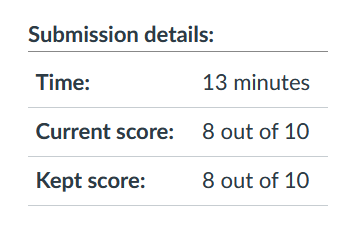

## Exercise 2: Install the required libraries and its dependences.

In [1]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install numpy

Defaulting to user installation because normal site-packages is not writeable


In [3]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [4]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


## Exercise 3: The first step of any Machine learning project is to determine a problem to solve and find a relevant dataset that can be used to train the model. In this example let us use the dataset we presented in the lecture i.e., the breast cancer classification.

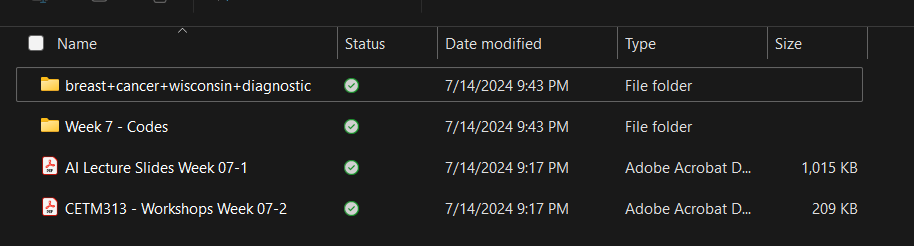

## Exercise 4: Initially we need to import the relevant libraries, as follows:

In [5]:
# Importing the libraries 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

Please note that we are using the breast cancer dataset, The dataset is hosted on the UCI website (Breast Cancer Wisconsin (Diagnostic) - UCI Machine Learning Repository), and you can also access it via the Sklearn library as follows:

In [6]:
# Use the dataset from ther sklearn library 
from sklearn.datasets import load_breast_cancer

## Exercise 5: To load the dataset, we can easily do the following:

In [7]:
# Loading the breast cancer dataset 
data = load_breast_cancer() 
X = data.data 
y = data.target 
feature_names = data.feature_names 
target_names = data.target_names

## Exercise 6: Now we can start analysing the dataset, to get a better understanding of it. Initially we can assess the classes distribution as follows:

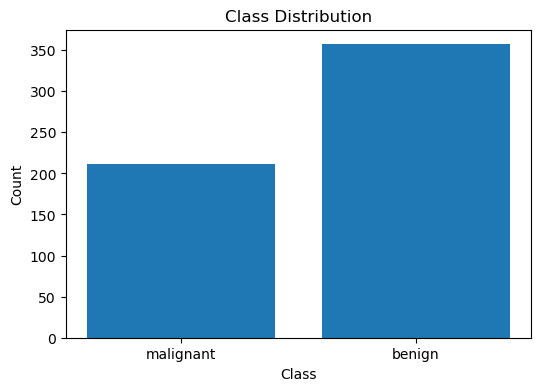

In [8]:
# Visualizing the classes distribution 
plt.figure(figsize=(6, 4)) 
plt.bar(target_names, np.bincount(y)) 
plt.xlabel('Class') 
plt.ylabel('Count') 
plt.title('Class Distribution') 
plt.show()

### Extra Task: Imbalanced Datasets

In [11]:
from sklearn.datasets import load_digits

digits = load_digits()
y = digits.target == 9

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, y, random_state=0)

In [12]:
from sklearn.dummy import DummyClassifier
dummy_majority = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
pred_most_frequent = dummy_majority.predict(X_test)
print("Unique predicted labels: {}".format(np.unique(pred_most_frequent)))
print("Test score: {:.2f}".format(dummy_majority.score(X_test, y_test)))

Unique predicted labels: [False]
Test score: 0.90


In [13]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=2).fit(X_train, y_train)
pred_tree = tree.predict(X_test)
print("Test score: {:.2f}".format(tree.score(X_test, y_test)))

Test score: 0.92


In [14]:
from sklearn.linear_model import LogisticRegression

dummy = DummyClassifier().fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)
print("dummy score: {:.2f}".format(dummy.score(X_test, y_test)))

logreg = LogisticRegression(C=0.1).fit(X_train, y_train)
pred_logreg = logreg.predict(X_test)
print("logreg score: {:.2f}".format(logreg.score(X_test, y_test)))

dummy score: 0.90
logreg score: 0.98


D:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


- Bias towards majority class: Models trained on imbalanced data favor the frequent class, leading to poor performance on the rarer, but important, minority class.

- Misleading metrics: Standard accuracy metrics can be deceptive. A model might just predict everything as the majority class and achieve high accuracy, masking its inability to identify the minority class.

- Evaluation challenges: Traditional evaluation metrics need to be replaced with those that consider performance on both majority and minority classes in imbalanced datasets.

## Exercise 7: To train a model that we can use in real world we need to ensure that it is able to classify correctly, thus it has learned the correct patters to be able to classify correctly. Thus we need to test it on a part of the data that it did not see in its training, i.e., the test set, and we can do it as follows:

In [23]:
# Splitting the dataset into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Extra Task: Read about overfitting via What is Overfitting? | IBM

When a model performs very well for training data but has poor performance with test data (new data), it is known as overfitting. In this case, the machine learning model learns the details and noise in the training data such that it negatively affects the model's performance on test data. Overfitting can happen due to low bias and high variance.

- Data used for training is not cleaned and contains noise (garbage values) in it
- The model has a high variance
- The size of the training dataset used is not enough
- The model is too complex

Real World Example:
- Like an examinee for a car driving license memorizing the signs and scenarios very well without understanding its definition for the map used for examination. As a result, he could have the license but also get an accident for a new scenario when occurring while driving on the real map.

## Exercise 8: To make sure that the model is able to use the features without any baise we need to scale that data as follows:

In [24]:
# Feature scaling 
scaler = StandardScaler() 
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)

### Extra Task: Read about scaling via chapter 3.3.1 of 3. Preprocessing | Introduction to Machine Learning with Python (oreilly.com)

In machine learning, scaling refers to a data pre-processing technique specifically focused on numerical features. It involves transforming those features to a common scale. This is crucial because the magnitude of features can significantly impact the performance of many machine learning algorithms.

Here's why scaling is important:
- Fair treatment for all features: Features with larger values can dominate the learning process if left unscaled. Scaling ensures all features contribute equally, regardless of their original unit or magnitude.
- Improved convergence: Certain algorithms, like gradient descent, take iterative steps to reach an optimal solution. Scaling can accelerate this process by ensuring the features are on a similar scale.
- Avoiding bias: Without scaling, features with larger values can introduce bias towards them during model training. Scaling prevents this by putting all features on an even footing.

There are different scaling techniques, each with its own advantages:
- Normalization: This technique scales features to a range of 0 to 1 (or -1 to 1). It's a good choice when the distribution of your features is important for the model.
- Standardization: This technique scales features to have a mean of 0 and a standard deviation of 1. It's particularly useful when the features have a Gaussian distribution.
- Min-Max Scaling: This technique scales features to a predefined minimum and maximum value (often 0 and 1). It's a simple and effective approach, but it can be sensitive to outliers.

## Exercise 9: So far, we have imported the data, and analysed it and did a simple scaling of the features. Consequently, now we can train the model on the training data as follows:

In [25]:
# Fitting logistic regression to the training set 
classifier = LogisticRegression(random_state=0) 
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

## Exercise 10: Since now we have a trained model, we can use it to predict the classes of the test data as follows:

In [26]:
# Predicting the test set results 
y_pred = classifier.predict(X_test)

## Exercise 11: To asse the performance of the classifier we can use the accuracy and other confusion matrix as follows:

In [27]:
# Evaluating the model 
print("Accuracy:", accuracy_score(y_test, y_pred)) 
print("\nClassification Report:\n", classification_report(y_test, y_pred)) 
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9736842105263158

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Confusion Matrix:
 [[41  2]
 [ 1 70]]


## Exercise 12: We can visualise the matrix as follows:

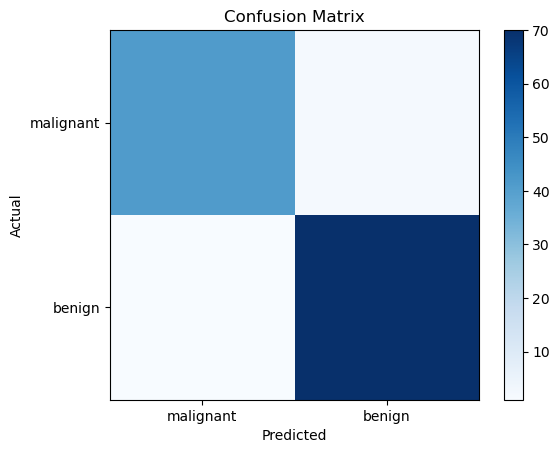

In [28]:
# Plotting the confusion matrix 
conf_matrix = confusion_matrix(y_test, y_pred) 
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest') 
plt.title('Confusion Matrix') 
plt.colorbar() 
tick_marks = np.arange(2) 
plt.xticks(tick_marks, target_names) 
plt.yticks(tick_marks, target_names) 
plt.xlabel('Predicted') 
plt.ylabel('Actual') 
plt.show()

## Exercise 13: We can also plot the ROC curve using:

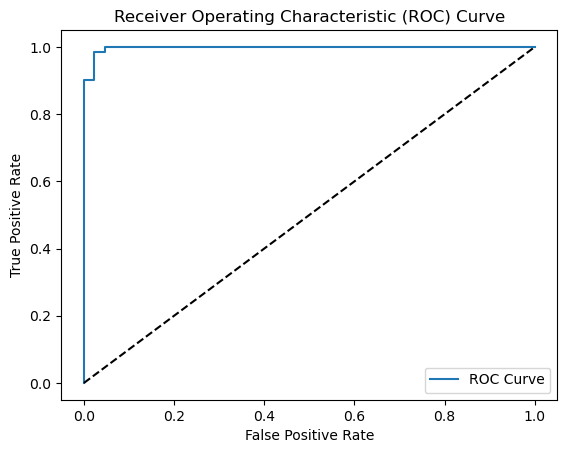

In [29]:
# Plotting the ROC curve 
y_pred_proba = classifier.predict_proba(X_test)[:, 1] 
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba) 
plt.plot(fpr, tpr, label='ROC Curve') 
plt.plot([0, 1], [0, 1], 'k--') 
plt.xlabel('False Positive Rate') 
plt.ylabel('True Positive Rate') 
plt.title('Receiver Operating Characteristic (ROC) Curve') 
plt.legend(loc='lower right') 
plt.show()

## Exercise 14: In real word scenarios we usually are very keen to use the classifiers to identify the most important features which can be ported to the medical experts and might lead to new discoveries and a better understanding of the science. Thus we can visualise the feature importance as follows:

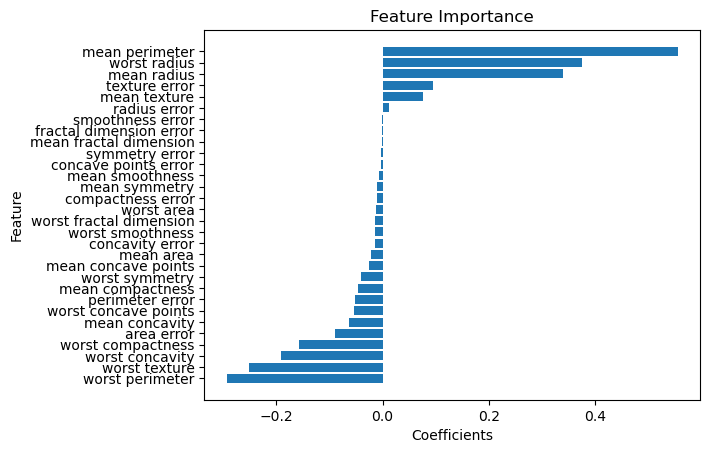

In [20]:
# Plotting feature importance 
coefficients = classifier.coef_[0] 
sorted_indices = np.argsort(coefficients) 
plt.barh(range(len(coefficients)), coefficients[sorted_indices], 
         tick_label=feature_names[sorted_indices]) 
plt.title('Feature Importance') 
plt.xlabel('Coefficients') 
plt.ylabel('Feature') 
plt.show()

## Exercise 15: Use different classification algorithms such as SVM and Decision Trees and compare the performance.

In [17]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Train SVM model
svm_model = SVC()
svm_model.fit(X_train, y_train)

# Train Decision Tree model
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

# Make predictions on test set
svm_pred = svm_model.predict(X_test)
dt_pred = dt_model.predict(X_test)

# Evaluate model performance
svm_accuracy = accuracy_score(y_test, svm_pred)
dt_accuracy = accuracy_score(y_test, dt_pred)

svm_report = classification_report(y_test, svm_pred)
dt_report = classification_report(y_test, dt_pred)

print("SVM Accuracy:", svm_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)

print("\nSVM Classification Report:\n", svm_report)
print("\nDecision Tree Classification Report:\n", dt_report)


SVM Accuracy: 0.9122807017543859
Decision Tree Accuracy: 0.9210526315789473

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.77      0.86        39
           1       0.89      0.99      0.94        75

    accuracy                           0.91       114
   macro avg       0.93      0.88      0.90       114
weighted avg       0.92      0.91      0.91       114


Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88        39
           1       0.93      0.95      0.94        75

    accuracy                           0.92       114
   macro avg       0.91      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114

